<a href="https://colab.research.google.com/github/spandana1320/B19_1320/blob/main/sesd(code).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔹 Logistic Regression Results:
Accuracy: 97.27 %
Precision: 99.34 %
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1206
           1       0.99      0.80      0.89       187

    accuracy                           0.97      1393
   macro avg       0.98      0.90      0.94      1393
weighted avg       0.97      0.97      0.97      1393



/tmp/ipython-input-2426294627.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette="Set2")


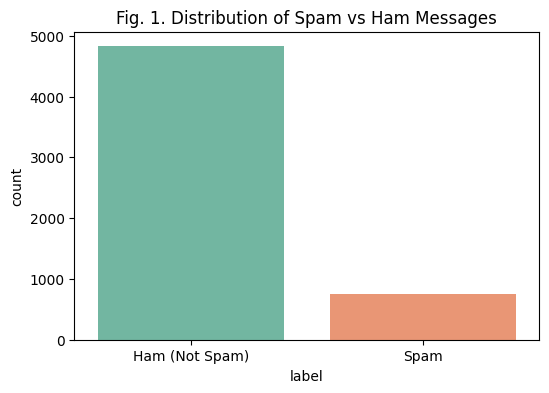

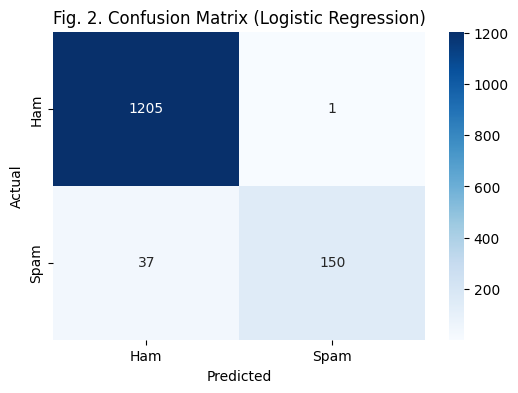

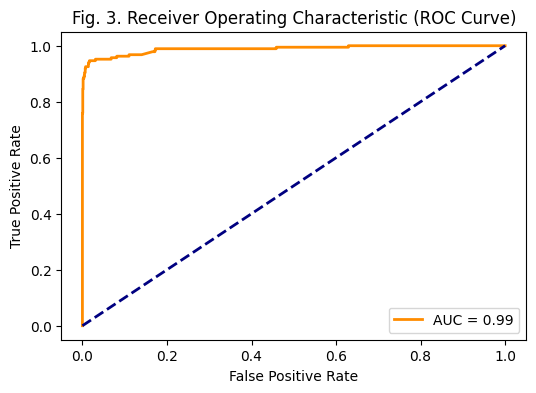

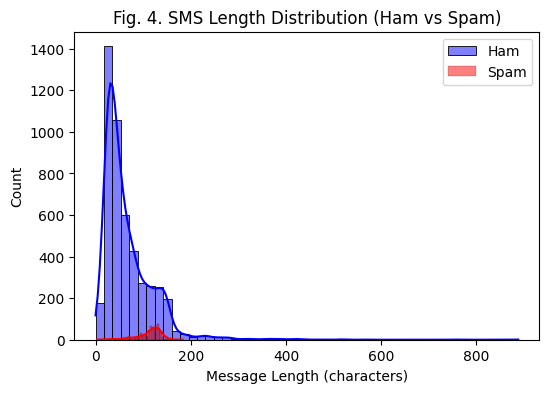

/tmp/ipython-input-2426294627.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[w for w,c in top_spam], y=[c for w,c in top_spam], palette="Reds_r")


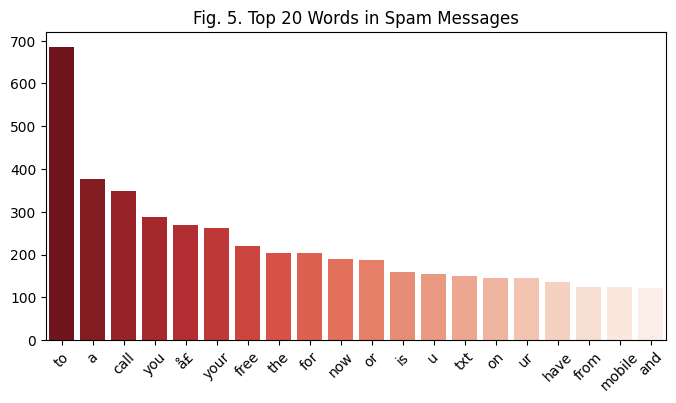

/tmp/ipython-input-2426294627.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[w for w,c in top_ham], y=[c for w,c in top_ham], palette="Blues_r")


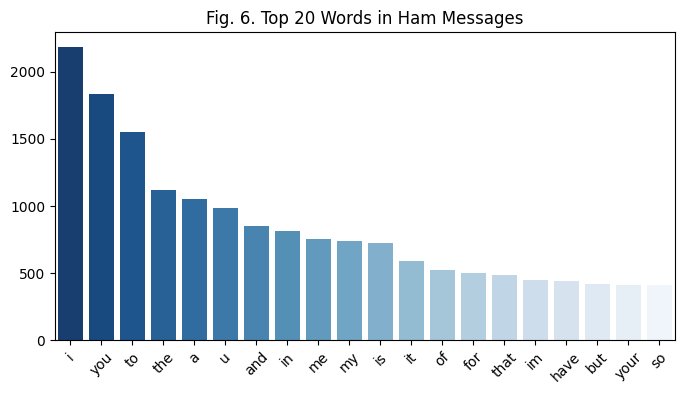

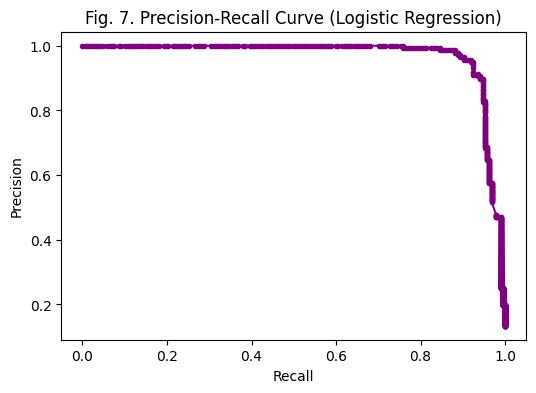

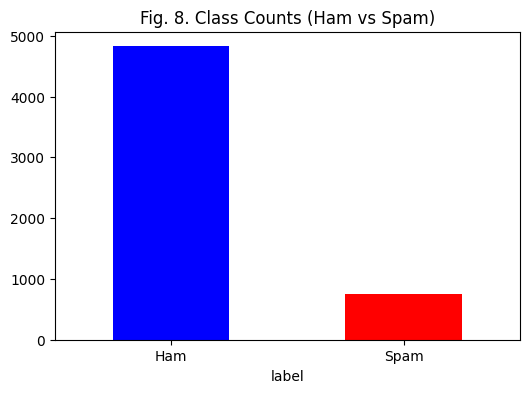

/tmp/ipython-input-2426294627.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[w for w,c in top_spam_bigrams], y=[c for w,c in top_spam_bigrams], palette="Reds_r")


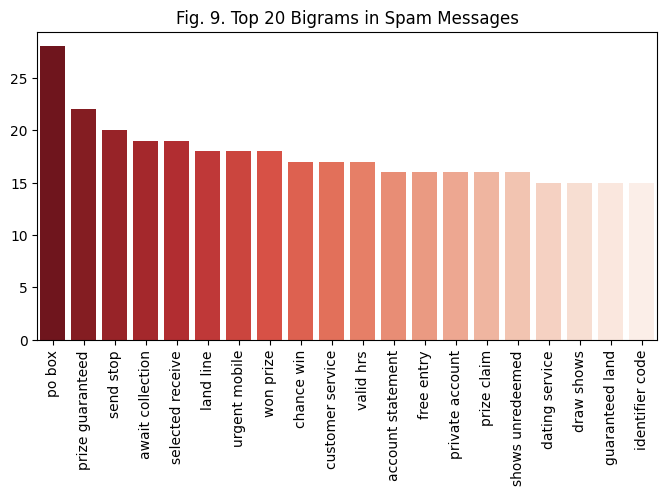

/tmp/ipython-input-2426294627.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[w for w,c in top_ham_bigrams], y=[c for w,c in top_ham_bigrams], palette="Blues_r")


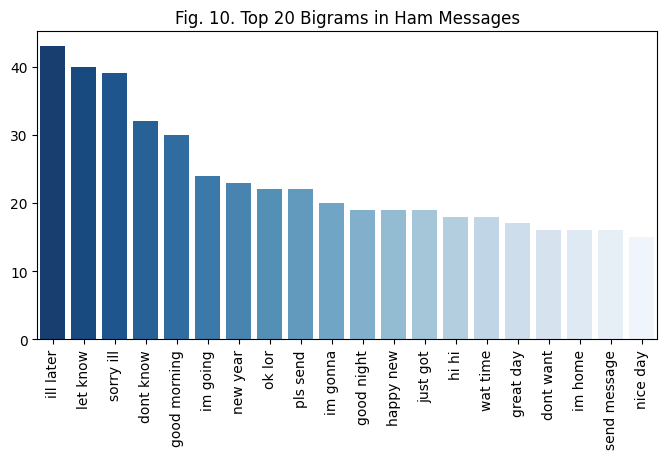

In [ ]:
# ============================================================
# SMS Spam Detection (with Complete Graphs & Visualizations)
# ============================================================

import pandas as pd
import re, string
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, classification_report,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------
df = pd.read_csv("/content/spam.csv", encoding="latin-1")

# Keep only useful columns
df = df[["v1", "v2"]]
df.columns = ["label", "text"]

# Encode labels
df["label"] = df["label"].map({"ham":0, "spam":1})

# ------------------------------------------------------------
# 2. Preprocessing
# ------------------------------------------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["text"] = df["text"].apply(clean_text)

# ------------------------------------------------------------
# 3. Train-Test Split
# ------------------------------------------------------------
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ------------------------------------------------------------
# 4. TF-IDF Vectorization
# ------------------------------------------------------------
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ------------------------------------------------------------
# 5. Logistic Regression
# ------------------------------------------------------------
lr = LogisticRegression(max_iter=3000, C=2, solver='lbfgs')
lr.fit(X_train_tfidf, y_train)
y_pred = lr.predict(X_test_tfidf)
y_pred_proba = lr.predict_proba(X_test_tfidf)[:,1]

print("🔹 Logistic Regression Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred)*100, 2), "%")
print(classification_report(y_test, y_pred))

# ------------------------------------------------------------
# 6. Visualizations
# ------------------------------------------------------------

# (a) Distribution of Spam vs Ham
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df, palette="Set2")
plt.xticks([0,1], ["Ham (Not Spam)", "Spam"])
plt.title("Fig. 1. Distribution of Spam vs Ham Messages")
plt.show()

# (b) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham","Spam"], yticklabels=["Ham","Spam"])
plt.title("Fig. 2. Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# (c) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fig. 3. Receiver Operating Characteristic (ROC Curve)")
plt.legend(loc="lower right")
plt.show()

# (d) SMS Length Distribution
df["length"] = df["text"].apply(len)
plt.figure(figsize=(6,4))
sns.histplot(df[df["label"]==0]["length"], color="blue", bins=50, label="Ham", kde=True)
sns.histplot(df[df["label"]==1]["length"], color="red", bins=50, label="Spam", kde=True)
plt.legend()
plt.title("Fig. 4. SMS Length Distribution (Ham vs Spam)")
plt.xlabel("Message Length (characters)")
plt.show()

# (e) Top 20 Words in Spam
spam_words = " ".join(df[df["label"]==1]["text"]).split()
spam_wc = Counter(spam_words)
top_spam = spam_wc.most_common(20)
plt.figure(figsize=(8,4))
sns.barplot(x=[w for w,c in top_spam], y=[c for w,c in top_spam], palette="Reds_r")
plt.title("Fig. 5. Top 20 Words in Spam Messages")
plt.xticks(rotation=45)
plt.show()

# (f) Top 20 Words in Ham
ham_words = " ".join(df[df["label"]==0]["text"]).split()
ham_wc = Counter(ham_words)
top_ham = ham_wc.most_common(20)
plt.figure(figsize=(8,4))
sns.barplot(x=[w for w,c in top_ham], y=[c for w,c in top_ham], palette="Blues_r")
plt.title("Fig. 6. Top 20 Words in Ham Messages")
plt.xticks(rotation=45)
plt.show()

# (g) Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, marker=".", color="purple")
plt.title("Fig. 7. Precision-Recall Curve (Logistic Regression)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# (h) Class Counts (Bar Plot)
plt.figure(figsize=(6,4))
df["label"].value_counts().plot(kind="bar", color=["blue","red"])
plt.title("Fig. 8. Class Counts (Ham vs Spam)")
plt.xticks([0,1], ["Ham","Spam"], rotation=0)
plt.show()

# (i) Top 20 Bigrams in Spam
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), stop_words="english").fit(df["text"])
spam_bigrams = bigram_vectorizer.transform(df[df["label"]==1]["text"])
spam_counts = spam_bigrams.sum(axis=0).A1
vocab = bigram_vectorizer.get_feature_names_out()
top_spam_bigrams = sorted(zip(vocab, spam_counts), key=lambda x: x[1], reverse=True)[:20]
plt.figure(figsize=(8,4))
sns.barplot(x=[w for w,c in top_spam_bigrams], y=[c for w,c in top_spam_bigrams], palette="Reds_r")
plt.title("Fig. 9. Top 20 Bigrams in Spam Messages")
plt.xticks(rotation=90)
plt.show()

# (j) Top 20 Bigrams in Ham
ham_bigrams = bigram_vectorizer.transform(df[df["label"]==0]["text"])
ham_counts = ham_bigrams.sum(axis=0).A1
top_ham_bigrams = sorted(zip(vocab, ham_counts), key=lambda x: x[1], reverse=True)[:20]
plt.figure(figsize=(8,4))
sns.barplot(x=[w for w,c in top_ham_bigrams], y=[c for w,c in top_ham_bigrams], palette="Blues_r")
plt.title("Fig. 10. Top 20 Bigrams in Ham Messages")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# ------------------------------------------------------------
# 6. Train Multiple Models & Compare Performance
# ------------------------------------------------------------
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, C=2),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append([name, acc, prec, rec, f1])

# Create DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print("\n==================== MODEL COMPARISON ====================")
print(results_df.to_string(index=False))



==================== MODEL COMPARISON ====================
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.972721   0.993377 0.802139  0.887574
        Naive Bayes  0.964106   0.992806 0.737968  0.846626
         Linear SVM  0.985642   0.988304 0.903743  0.944134
      Random Forest  0.974874   0.993506 0.818182  0.897361
          KNN (k=5)  0.912419   1.000000 0.347594  0.515873


In [3]:
# ------------------------------------------------------------
# Train Multiple Models & Create Individual Tables
# ------------------------------------------------------------
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, C=2),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    # Create table for each model
    df_table = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Value": [acc, prec, rec, f1]
    })

    print("\n========================================")
    print(f"🔹 PERFORMANCE TABLE — {name}")
    print("========================================")
    print(df_table.to_string(index=False))



🔹 PERFORMANCE TABLE — Logistic Regression
   Metric    Value
 Accuracy 0.972721
Precision 0.993377
   Recall 0.802139
 F1-Score 0.887574

🔹 PERFORMANCE TABLE — Naive Bayes
   Metric    Value
 Accuracy 0.964106
Precision 0.992806
   Recall 0.737968
 F1-Score 0.846626

🔹 PERFORMANCE TABLE — Linear SVM
   Metric    Value
 Accuracy 0.985642
Precision 0.988304
   Recall 0.903743
 F1-Score 0.944134

🔹 PERFORMANCE TABLE — Random Forest
   Metric    Value
 Accuracy 0.976310
Precision 0.993590
   Recall 0.828877
 F1-Score 0.903790

🔹 PERFORMANCE TABLE — KNN (k=5)
   Metric    Value
 Accuracy 0.912419
Precision 1.000000
   Recall 0.347594
 F1-Score 0.515873


In [4]:
# ------------------------------------------------------------
# Multiple Models – 5 Trials Each – Tables with Values
# ------------------------------------------------------------
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, C=2),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

for model_name, model in models.items():

    all_precision = []
    all_recall = []
    all_f1 = []

    # --------------------------
    # Run 5 Trials
    # --------------------------
    for trial in range(5):

        X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
            X, y, test_size=0.25, random_state=42 + trial, stratify=y
        )

        # Transform using TF-IDF fitted earlier
        X_train_tf = tfidf.fit_transform(X_train_t)
        X_test_tf = tfidf.transform(X_test_t)

        # Train model
        model.fit(X_train_tf, y_train_t)
        preds = model.predict(X_test_tf)

        # Metrics
        prec = precision_score(y_test_t, preds)
        rec = recall_score(y_test_t, preds)
        f1 = f1_score(y_test_t, preds)

        all_precision.append(prec)
        all_recall.append(rec)
        all_f1.append(f1)

    # Create table
    df_table = pd.DataFrame({
        "Trial": [f"Trial {i}" for i in range(1, 5+1)],
        "Precision": all_precision,
        "Recall": all_recall,
        "F1-Score": all_f1
    })

    # Add averages
    df_table.loc["Average"] = [
        "Average",
        df_table["Precision"].mean(),
        df_table["Recall"].mean(),
        df_table["F1-Score"].mean()
    ]

    # Print table
    print("\n========================================")
    print(f"🔹 PERFORMANCE TABLE — {model_name}")
    print("========================================")
    print(df_table.to_string(index=False))



🔹 PERFORMANCE TABLE — Logistic Regression
  Trial  Precision   Recall  F1-Score
Trial 1   0.993377 0.802139  0.887574
Trial 2   0.987654 0.855615  0.916905
Trial 3   0.986667 0.791444  0.878338
Trial 4   0.986577 0.786096  0.875000
Trial 5   0.967320 0.791444  0.870588
Average   0.984319 0.805348  0.885681

🔹 PERFORMANCE TABLE — Naive Bayes
  Trial  Precision   Recall  F1-Score
Trial 1   0.992806 0.737968  0.846626
Trial 2   1.000000 0.812834  0.896755
Trial 3   1.000000 0.743316  0.852761
Trial 4   1.000000 0.775401  0.873494
Trial 5   1.000000 0.759358  0.863222
Average   0.998561 0.765775  0.866572

🔹 PERFORMANCE TABLE — Linear SVM
  Trial  Precision   Recall  F1-Score
Trial 1   0.988304 0.903743  0.944134
Trial 2   0.983051 0.930481  0.956044
Trial 3   0.982353 0.893048  0.935574
Trial 4   0.988235 0.898396  0.941176
Trial 5   0.959770 0.893048  0.925208
Average   0.980343 0.903743  0.940427

🔹 PERFORMANCE TABLE — Random Forest
  Trial  Precision   Recall  F1-Score
Trial 1   0.993

In [5]:
# ------------------------------------------------------------
# 6. Train Multiple Models with 5 Trials + Comparative Table
# ------------------------------------------------------------
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, C=2),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

overall_results = []   # for final comparative table

# ------------------------------------------------------------
# Run 5 Trials per Model
# ------------------------------------------------------------
for model_name, model in models.items():

    trial_accuracy = []
    trial_precision = []
    trial_recall = []
    trial_f1 = []

    for trial in range(1, 6):

        # Different random state each trial
        X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
            X, y, test_size=0.25,
            random_state=42 + trial, stratify=y
        )

        # TF-IDF vectorization (fit only on training data)
        X_train_tf = tfidf.fit_transform(X_train_t)
        X_test_tf = tfidf.transform(X_test_t)

        # Train model
        model.fit(X_train_tf, y_train_t)
        preds = model.predict(X_test_tf)

        # Compute metrics
        acc = accuracy_score(y_test_t, preds)
        prec = precision_score(y_test_t, preds)
        rec = recall_score(y_test_t, preds)
        f1 = f1_score(y_test_t, preds)

        # Append this trial’s values
        trial_accuracy.append(acc)
        trial_precision.append(prec)
        trial_recall.append(rec)
        trial_f1.append(f1)

    # ------------------------------------------------------------
    # Create Trial Table for the Model
    # ------------------------------------------------------------
    df_table = pd.DataFrame({
        "Trial": [f"Trial {i}" for i in range(1, 6)],
        "Accuracy": trial_accuracy,
        "Precision": trial_precision,
        "Recall": trial_recall,
        "F1-Score": trial_f1
    })

    # Add average row
    df_table.loc["Average"] = [
        "Average",
        df_table["Accuracy"].mean(),
        df_table["Precision"].mean(),
        df_table["Recall"].mean(),
        df_table["F1-Score"].mean()
    ]

    # Print table
    print("\n====================================================")
    print(f"🔹 PERFORMANCE TABLE — {model_name}")
    print("====================================================")
    print(df_table.to_string(index=False))

    # Store into final comparative table
    overall_results.append([
        model_name,
        df_table.loc["Average", "Accuracy"],
        df_table.loc["Average", "Precision"],
        df_table.loc["Average", "Recall"],
        df_table.loc["Average", "F1-Score"]
    ])

# ------------------------------------------------------------
# Create Final Comparative Table
# ------------------------------------------------------------
overall_df = pd.DataFrame(
    overall_results,
    columns=["Model", "Avg Accuracy", "Avg Precision", "Avg Recall", "Avg F1-Score"]
)

print("\n==================== OVERALL MODEL COMPARISON ====================")
print(overall_df.to_string(index=False))



🔹 PERFORMANCE TABLE — Logistic Regression
  Trial  Accuracy  Precision   Recall  F1-Score
Trial 1  0.979182   0.987654 0.855615  0.916905
Trial 2  0.970567   0.986667 0.791444  0.878338
Trial 3  0.969849   0.986577 0.786096  0.875000
Trial 4  0.968413   0.967320 0.791444  0.870588
Trial 5  0.967696   0.973333 0.780749  0.866469
Average  0.971141   0.980310 0.801070  0.881460

🔹 PERFORMANCE TABLE — Naive Bayes
  Trial  Accuracy  Precision   Recall  F1-Score
Trial 1  0.974874        1.0 0.812834  0.896755
Trial 2  0.965542        1.0 0.743316  0.852761
Trial 3  0.969849        1.0 0.775401  0.873494
Trial 4  0.967696        1.0 0.759358  0.863222
Trial 5  0.966978        1.0 0.754011  0.859756
Average  0.968988        1.0 0.768984  0.869198

🔹 PERFORMANCE TABLE — Linear SVM
  Trial  Accuracy  Precision   Recall  F1-Score
Trial 1  0.988514   0.983051 0.930481  0.956044
Trial 2  0.983489   0.982353 0.893048  0.935574
Trial 3  0.984925   0.988235 0.898396  0.941176
Trial 4  0.980617   0.95